# Projekat (iz predloga): koaliciona TU igra u mikro-mreži (PV + baterije + pooling)

Ovaj notebook **postavlja i rešava** problem iz predloga projekta:

1) Rešava „solo“ optimizaciju za svaku kuću \(i\):
\[
C^{solo}_i = \min \sum_t ig(c_{buy}(t)\,Import_i(t) - c_{sell}(t)\,Export_i(t)ig)
\]
uz bilans po satu:
\[
Import_i(t) + G_i(t) + Dis_i(t) = L_i(t) + Ch_i(t) + Export_i(t)
\]
i ograničenja baterije/SOC.

2) Rešava koalicioni (pooling) problem za svaku koaliciju \(S\):
\[
C^{coal}_S = \min \sum_t ig(c_{buy}(t)\,Import_S(t) - c_{sell}(t)\,Export_S(t)ig)
\]
gde je koalicija u stanju da interno razmenjuje energiju (idealno bez troška), pa mreža „vidi“ samo agregirani neto bilans.

3) Definiše karakterističnu funkciju (vrednost koalicije kao ušteda):
\[
v(S) = \Big(\sum_{i\in S} C^{solo}_i\Big) - C^{coal}_S
\]

4) Računa raspodele: **Shapley**, **core test**, i **least-core** (min \(
arepsilon\)).

> Napomena: Primer ispod generiše sintetičke profile (24h). U praksi samo zameni `L` i `G` realnim profilima.


## 0) Importi

In [10]:
%matplotlib inline

import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog
from IPython.display import display

np.random.seed(4)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [11]:
def build_buy_price(tou=False, stress=False):
    price = np.full(24, 0.18)

    if tou:
        price[:7] = 0.20
        price[7:17] = 0.16
        price[17:23] = 0.28

    if stress:
        price[10:16] = 0.14
        price[17:23] = 0.30

    return price


def build_sell_price(low=False):
    return np.full(24, 0.05 if low else 0.08)


def base_load_curve():
    h = np.arange(24)
    morning = 0.9 * np.exp(-0.5 * ((h - 7) / 1.6) ** 2)
    evening = 1.5 * np.exp(-0.5 * ((h - 20) / 2.1) ** 2)
    base = 0.55 + 0.08 * np.cos((h - 2) / 24 * 2 * np.pi)
    return base + morning + evening


def base_pv_curve():
    h = np.arange(24)
    pv = 2.6 * np.exp(-0.5 * ((h - 12) / 2.2) ** 2)
    pv[(h < 6) | (h > 18)] = 0.0
    return pv


def make_profiles(n, pv_houses, load_scales, pv_scales):
    load_ref = base_load_curve()
    pv_ref = base_pv_curve()

    rng = np.random.default_rng(100 + n + len(pv_houses))

    load = []
    pv = []

    for i in range(n):
        load_noise = 1.0 + 0.06 * rng.normal(size=24)
        load_i = np.clip(load_scales[i] * load_ref * load_noise, 0.2, None)
        load.append(load_i)

        if i in pv_houses:
            pv_noise = 1.0 + 0.05 * rng.normal(size=24)
            pv_i = np.clip(pv_scales[i] * pv_ref * pv_noise, 0.0, None)
        else:
            pv_i = np.zeros(24)

        pv.append(pv_i)

    return np.array(load), np.array(pv)


def build_scenario(name):
    if name == "scenario_1":
        # 5 households, 2 with PV, 1 with battery
        n = 5
        pv_houses = {0, 2}
        battery_houses = {1}

        load_scales = np.array([1.00, 1.15, 0.95, 0.85, 1.05])
        pv_scales = np.array([1.05, 0.0, 0.95, 0.0, 0.0])

        buy_price = build_buy_price(tou=False, stress=False)
        sell_price = build_sell_price(low=False)

    elif name == "scenario_2":
        # 8 households, 4 with PV, 3 with batteries, TOU pricing
        n = 8
        pv_houses = {0, 2, 4, 6}
        battery_houses = {3, 5, 7}

        load_scales = np.array([0.95, 1.00, 1.05, 1.20, 0.90, 1.15, 1.00, 1.10])
        pv_scales = np.array([1.00, 0.0, 0.90, 0.0, 1.10, 0.0, 1.00, 0.0])

        buy_price = build_buy_price(tou=True, stress=False)
        sell_price = build_sell_price(low=False)

    elif name == "scenario_3":
        # 8 households, high PV penetration, low sell price
        n = 8
        pv_houses = {0, 1, 2, 3, 4}
        battery_houses = {5, 6, 7}

        load_scales = np.array([0.80, 0.85, 0.90, 0.95, 0.85, 1.20, 1.25, 1.30])
        pv_scales = np.array([1.20, 1.10, 1.15, 1.05, 1.00, 0.0, 0.0, 0.0])

        buy_price = build_buy_price(tou=True, stress=True)
        sell_price = build_sell_price(low=True)

    else:
        raise ValueError("Unknown scenario name.")

    players = [f"H{i+1}" for i in range(n)]
    load, pv = make_profiles(n, pv_houses, load_scales, pv_scales)

    battery_capacity = np.zeros(n)
    battery_power = np.zeros(n)

    for i in battery_houses:
        battery_capacity[i] = 4.0 if name == "scenario_1" else 5.0
        battery_power[i] = 2.0

    soc0 = 0.5 * battery_capacity

    return {
        "name": name,
        "players": players,
        "hours": np.arange(24),
        "T": 24,
        "load": load,
        "pv": pv,
        "battery_capacity": battery_capacity,
        "battery_power": battery_power,
        "soc0": soc0,
        "battery_efficiency": 0.95,
        "buy_price": buy_price,
        "sell_price": sell_price,
    }

In [12]:
def plot_input_profiles(scenario):
    hours = scenario["hours"]
    players = scenario["players"]
    load = scenario["load"]
    pv = scenario["pv"]

    plt.figure(figsize=(10, 4))
    for i, p in enumerate(players):
        plt.plot(hours, load[i], label=p)
    plt.title(f"Household load profiles | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Load [kWh]")
    plt.legend(ncol=min(4, len(players)))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    for i, p in enumerate(players):
        if pv[i].sum() > 1e-12:
            plt.plot(hours, pv[i], label=p)
    plt.title(f"PV generation profiles | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("PV generation [kWh]")
    plt.legend(ncol=min(4, len(players)))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hours, scenario["buy_price"], label="Buy price")
    plt.plot(hours, scenario["sell_price"], label="Sell price")
    plt.title(f"Price profiles | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Price [EUR/kWh]")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
def coalition_label(S):
    return "+".join(sorted(S))


def all_coalitions(players):
    coalitions = []
    for r in range(1, len(players) + 1):
        for comb in itertools.combinations(players, r):
            coalitions.append(frozenset(comb))
    return coalitions


def solve_coalition_lp(scenario, members, return_details=False):
    """
    Simple coalition LP:
    - local batteries remain local,
    - energy pooling is represented through coalition-level grid import/export,
    - terminal SOC is fixed to initial SOC.
    """
    players = scenario["players"]
    idx = [players.index(m) for m in members]

    T = scenario["T"]
    load = scenario["load"][idx]
    pv = scenario["pv"][idx]
    cap = scenario["battery_capacity"][idx]
    pmax = scenario["battery_power"][idx]
    soc0 = scenario["soc0"][idx]
    eta = scenario["battery_efficiency"]
    m = len(idx)

    # Variables:
    # import[t], export[t],
    # charge[j,t], discharge[j,t],
    # soc[j,t] for t=0..T
    n_grid = 2 * T
    n_batt = 2 * m * T + m * (T + 1)
    nvar = n_grid + n_batt

    def i_import(t):
        return t

    def i_export(t):
        return T + t

    def i_charge(j, t):
        return 2 * T + j * T + t

    def i_discharge(j, t):
        return 2 * T + m * T + j * T + t

    def i_soc(j, t):
        return 2 * T + 2 * m * T + j * (T + 1) + t

    c = np.zeros(nvar)

    for t in range(T):
        c[i_import(t)] = scenario["buy_price"][t] + 1e-6
        c[i_export(t)] = -scenario["sell_price"][t] + 1e-6

    for j in range(m):
        for t in range(T):
            c[i_charge(j, t)] = 1e-6
            c[i_discharge(j, t)] = 1e-6

    A_eq = []
    b_eq = []

    # Coalition-level energy balance per hour
    for t in range(T):
        row = np.zeros(nvar)
        row[i_import(t)] = 1.0
        row[i_export(t)] = -1.0

        for j in range(m):
            row[i_charge(j, t)] -= 1.0
            row[i_discharge(j, t)] += 1.0

        A_eq.append(row)
        b_eq.append(float(np.sum(load[:, t] - pv[:, t])))

    # Battery initial SOC, dynamics, and terminal SOC
    for j in range(m):
        row = np.zeros(nvar)
        row[i_soc(j, 0)] = 1.0
        A_eq.append(row)
        b_eq.append(float(soc0[j]))

        for t in range(T):
            row = np.zeros(nvar)
            row[i_soc(j, t + 1)] = 1.0
            row[i_soc(j, t)] = -1.0
            row[i_charge(j, t)] = -eta
            row[i_discharge(j, t)] = 1.0 / eta
            A_eq.append(row)
            b_eq.append(0.0)

        row = np.zeros(nvar)
        row[i_soc(j, T)] = 1.0
        A_eq.append(row)
        b_eq.append(float(soc0[j]))

    bounds = []

    # import[t]
    for _ in range(T):
        bounds.append((0, None))

    # export[t]
    for _ in range(T):
        bounds.append((0, None))

    # charge[j,t]
    for j in range(m):
        for _ in range(T):
            bounds.append((0, float(pmax[j])))

    # discharge[j,t]
    for j in range(m):
        for _ in range(T):
            bounds.append((0, float(pmax[j])))

    # soc[j,t]
    for j in range(m):
        for _ in range(T + 1):
            bounds.append((0, float(cap[j])))

    res = linprog(
        c=c,
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        raise RuntimeError(res.message)

    total_cost = float(res.fun)

    if not return_details:
        return total_cost

    x = res.x

    return {
        "cost": total_cost,
        "grid_import": np.array([x[i_import(t)] for t in range(T)]),
        "grid_export": np.array([x[i_export(t)] for t in range(T)]),
    }

In [14]:
def compute_game(scenario):
    players = scenario["players"]
    coalitions = all_coalitions(players)

    solo_cost = {}
    solo_profiles = {}
    coalition_cost = {}

    for p in players:
        out = solve_coalition_lp(scenario, [p], return_details=True)
        solo_cost[p] = out["cost"]
        solo_profiles[p] = out
        coalition_cost[frozenset({p})] = out["cost"]

    v = {}

    for S in coalitions:
        if S not in coalition_cost:
            coalition_cost[S] = solve_coalition_lp(scenario, sorted(S), return_details=False)

        v[S] = sum(solo_cost[p] for p in S) - coalition_cost[S]

    grand = solve_coalition_lp(scenario, players, return_details=True)

    return {
        "solo_cost": solo_cost,
        "solo_profiles": solo_profiles,
        "coalition_cost": coalition_cost,
        "v": v,
        "grand": grand,
    }


def shapley_value(players, v):
    players = list(players)
    n = len(players)
    phi = {p: 0.0 for p in players}

    for p in players:
        others = [q for q in players if q != p]

        for r in range(len(others) + 1):
            for comb in itertools.combinations(others, r):
                S = frozenset(comb)
                weight = (
                    math.factorial(len(S))
                    * math.factorial(n - len(S) - 1)
                    / math.factorial(n)
                )
                phi[p] += weight * (v[S | {p}] - v.get(S, 0.0))

    return phi


def equal_split(players, vN):
    return {p: vN / len(players) for p in players}


def pv_proportional(scenario, vN):
    totals = scenario["pv"].sum(axis=1)

    if totals.sum() <= 1e-12:
        return equal_split(scenario["players"], vN)

    return {
        p: vN * totals[i] / totals.sum()
        for i, p in enumerate(scenario["players"])
    }


def contribution_proportional(scenario, vN):
    # Simple heuristic:
    # positive net surplus potential = max(PV - load, 0)
    contribution = np.maximum(scenario["pv"] - scenario["load"], 0.0).sum(axis=1)

    if contribution.sum() <= 1e-12:
        return equal_split(scenario["players"], vN)

    return {
        p: vN * contribution[i] / contribution.sum()
        for i, p in enumerate(scenario["players"])
    }


def least_core(players, v):
    players = list(players)
    n = len(players)
    coalitions = all_coalitions(players)

    # Variables: x_1 ... x_n, eps
    c = np.zeros(n + 1)
    c[-1] = 1.0

    A_ub = []
    b_ub = []

    for S in coalitions:
        row = np.zeros(n + 1)

        for i, p in enumerate(players):
            if p in S:
                row[i] = -1.0

        row[-1] = -1.0
        A_ub.append(row)
        b_ub.append(-v[S])

    A_eq = np.zeros((1, n + 1))
    A_eq[0, :n] = 1.0
    b_eq = np.array([v[frozenset(players)]])

    bounds = [(0, None)] * n + [(0, None)]

    res = linprog(
        c=c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        raise RuntimeError(res.message)

    x = {players[i]: float(res.x[i]) for i in range(n)}
    eps = float(res.x[-1])

    return x, eps


def core_violations(players, v, allocation, tol=1e-9):
    rows = []

    for S in all_coalitions(players):
        lhs = sum(allocation[p] for p in S)
        deficit = v[S] - lhs

        if deficit > tol:
            rows.append({
                "coalition": coalition_label(S),
                "size": len(S),
                "v_S": v[S],
                "sum_x": lhs,
                "deficit": deficit,
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return pd.DataFrame(columns=["coalition", "size", "v_S", "sum_x", "deficit"])

    return df.sort_values(["deficit", "size"], ascending=[False, True]).reset_index(drop=True)


def gini(values):
    x = np.array(values, dtype=float)
    if np.allclose(x.sum(), 0.0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return float((2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n)


def run_analysis(scenario):
    game = compute_game(scenario)
    players = scenario["players"]
    v = game["v"]
    vN = v[frozenset(players)]

    shapley = shapley_value(players, v)
    x_lc, eps_lc = least_core(players, v)

    allocations = {
        "shapley": shapley,
        "least_core": x_lc,
        "equal_split": equal_split(players, vN),
        "pv_proportional": pv_proportional(scenario, vN),
        "contribution_proportional": contribution_proportional(scenario, vN),
    }

    stability = {
        method: core_violations(players, v, allocation)
        for method, allocation in allocations.items()
    }

    return {
        "scenario": scenario,
        "game": game,
        "allocations": allocations,
        "stability": stability,
        "least_core_eps": eps_lc,
    }

In [15]:
def safe_percent(numerator, denominator):
    if abs(denominator) < 1e-12:
        return 0.0
    return 100.0 * numerator / denominator


def build_import_export_table(result):
    scenario = result["scenario"]
    players = scenario["players"]
    T = scenario["T"]

    solo_import = np.zeros(T)
    solo_export = np.zeros(T)

    for p in players:
        solo_import += result["game"]["solo_profiles"][p]["grid_import"]
        solo_export += result["game"]["solo_profiles"][p]["grid_export"]

    grand_import = result["game"]["grand"]["grid_import"]
    grand_export = result["game"]["grand"]["grid_export"]

    import_reduction = np.divide(
        100.0 * (solo_import - grand_import),
        solo_import,
        out=np.zeros_like(solo_import),
        where=solo_import > 1e-12,
    )

    export_reduction = np.divide(
        100.0 * (solo_export - grand_export),
        solo_export,
        out=np.zeros_like(solo_export),
        where=solo_export > 1e-12,
    )

    return pd.DataFrame({
        "hour": scenario["hours"],
        "solo_import": solo_import,
        "grand_import": grand_import,
        "solo_export": solo_export,
        "grand_export": grand_export,
        "import_reduction_percent": import_reduction,
        "export_reduction_percent": export_reduction,
    })


def build_method_summary(result):
    scenario = result["scenario"]
    players = scenario["players"]
    vN = result["game"]["v"][frozenset(players)]

    rows = []

    for method, allocation in result["allocations"].items():
        df_viol = result["stability"][method]

        rows.append({
            "method": method,
            "sum_allocation": sum(allocation.values()),
            "grand_coalition_value": vN,
            "blocking_coalitions": len(df_viol),
            "worst_deficit": float(df_viol["deficit"].max()) if len(df_viol) else 0.0,
            "in_core": len(df_viol) == 0,
            "gini": gini(list(allocation.values())),
        })

    return pd.DataFrame(rows).sort_values("blocking_coalitions")


def build_household_table(result):
    scenario = result["scenario"]
    players = scenario["players"]
    vN = result["game"]["v"][frozenset(players)]

    rows = []

    for p in players:
        row = {"household": p}
        for method, allocation in result["allocations"].items():
            row[f"{method}_eur"] = allocation[p]
            row[f"{method}_share_percent"] = safe_percent(allocation[p], vN)
        rows.append(row)

    return pd.DataFrame(rows)


def build_system_summary(result):
    scenario = result["scenario"]
    players = scenario["players"]
    vN = result["game"]["v"][frozenset(players)]

    df = build_import_export_table(result)

    total_pv = float(np.sum(scenario["pv"]))
    solo_self_consumption = total_pv - df["solo_export"].sum()
    grand_self_consumption = total_pv - df["grand_export"].sum()

    solo_self_consumption_ratio = safe_percent(solo_self_consumption, total_pv)
    grand_self_consumption_ratio = safe_percent(grand_self_consumption, total_pv)

    return pd.DataFrame({
        "metric": [
            "Grand coalition savings [EUR]",
            "Peak import reduction [%]",
            "PV self-consumption before sharing [%]",
            "PV self-consumption after sharing [%]",
            "PV self-consumption improvement [pp]",
        ],
        "value": [
            vN,
            safe_percent(df["solo_import"].max() - df["grand_import"].max(), df["solo_import"].max()),
            solo_self_consumption_ratio,
            grand_self_consumption_ratio,
            grand_self_consumption_ratio - solo_self_consumption_ratio,
        ],
    })


def plot_allocation_bars(result, percent=False):
    scenario = result["scenario"]
    players = scenario["players"]
    methods = [
        "shapley",
        "least_core",
        "equal_split",
        "pv_proportional",
        "contribution_proportional",
    ]

    if percent:
        vN = result["game"]["v"][frozenset(players)]
        data = {
            method: [safe_percent(result["allocations"][method][p], vN) for p in players]
            for method in methods
        }
        ylabel = "Share of total savings [%]"
        title = f"Allocation shares by method | {scenario['name']}"
    else:
        data = {
            method: [result["allocations"][method][p] for p in players]
            for method in methods
        }
        ylabel = "Allocated savings [EUR]"
        title = f"Savings allocation by method | {scenario['name']}"

    df = pd.DataFrame(data, index=players)
    df.plot(kind="bar", figsize=(10, 4))
    plt.title(title)
    plt.xlabel("Household")
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_coalition_values(result, percent=False):
    scenario = result["scenario"]
    players = scenario["players"]
    v = result["game"]["v"]
    vN = v[frozenset(players)]

    rows = []

    for S, val in v.items():
        rows.append({
            "size": len(S),
            "value": val,
            "value_percent": safe_percent(val, vN),
        })

    df = pd.DataFrame(rows)

    plt.figure(figsize=(8, 4))

    for size in sorted(df["size"].unique()):
        subset = df[df["size"] == size]
        y = subset["value_percent"] if percent else subset["value"]
        plt.scatter([size] * len(subset), y, alpha=0.65)

    plt.xlabel("Coalition size |S|")
    plt.ylabel("Coalition value [% of v(N)]" if percent else "Coalition savings v(S) [EUR]")
    plt.title(f"Coalition value by size | {scenario['name']}")
    plt.tight_layout()
    plt.show()


def plot_import_export_profiles(result):
    scenario = result["scenario"]
    df = build_import_export_table(result)

    plt.figure(figsize=(10, 4))
    plt.plot(df["hour"], df["solo_import"], label="Solo total import")
    plt.plot(df["hour"], df["grand_import"], label="Coalition import")
    plt.title(f"Grid import profile | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(df["hour"], df["solo_export"], label="Solo total export")
    plt.plot(df["hour"], df["grand_export"], label="Coalition export")
    plt.title(f"Grid export profile | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(df["hour"], df["import_reduction_percent"])
    plt.title(f"Grid import reduction | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Reduction vs solo [%]")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(df["hour"], df["export_reduction_percent"])
    plt.title(f"Grid export reduction | {scenario['name']}")
    plt.xlabel("Hour")
    plt.ylabel("Reduction vs solo [%]")
    plt.tight_layout()
    plt.show()


def plot_blocking_heatmap(result, method="shapley", top_n=20, percent=False):
    scenario = result["scenario"]
    players = scenario["players"]
    df = result["stability"][method].head(top_n).copy()

    if len(df) == 0:
        print(f"No blocking coalitions for {method}.")
        return

    if percent:
        vN = result["game"]["v"][frozenset(players)]
        values = np.array([safe_percent(d, vN) for d in df["deficit"]])
        cbar_label = "Blocking deficit [% of v(N)]"
    else:
        values = df["deficit"].to_numpy()
        cbar_label = "Deficit [EUR]"

    mat = np.zeros((len(df), len(players)))

    for r, label in enumerate(df["coalition"]):
        members = set(label.split("+"))
        for c, p in enumerate(players):
            mat[r, c] = values[r] if p in members else 0.0

    plt.figure(figsize=(10, max(4, 0.4 * len(df) + 1)))
    plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(players)), players)
    plt.yticks(range(len(df)), df["coalition"])
    plt.colorbar(label=cbar_label)
    plt.title(f"Top blocking coalitions | {method} | {scenario['name']}")
    plt.xlabel("Household")
    plt.ylabel("Coalition")
    plt.tight_layout()
    plt.show()

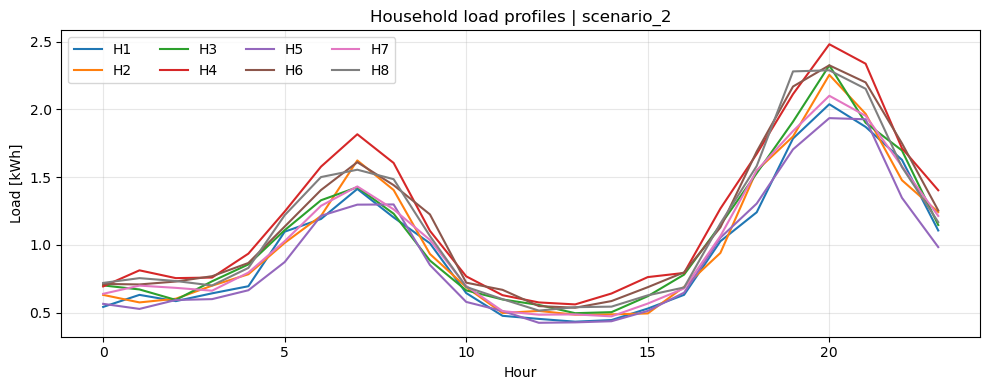

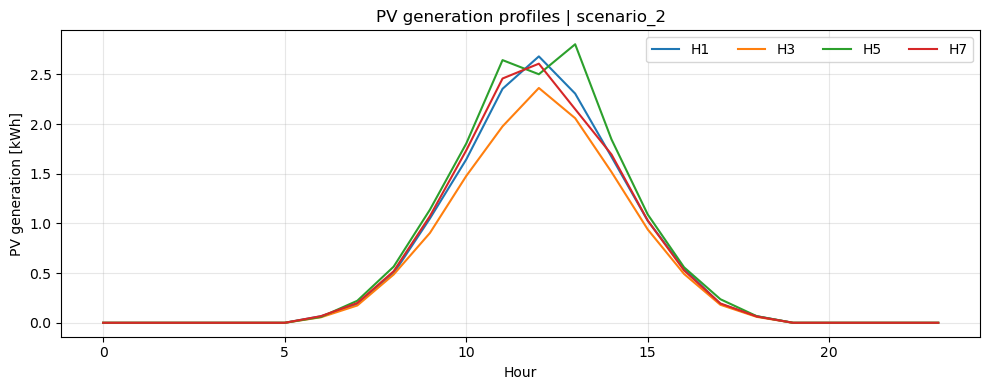

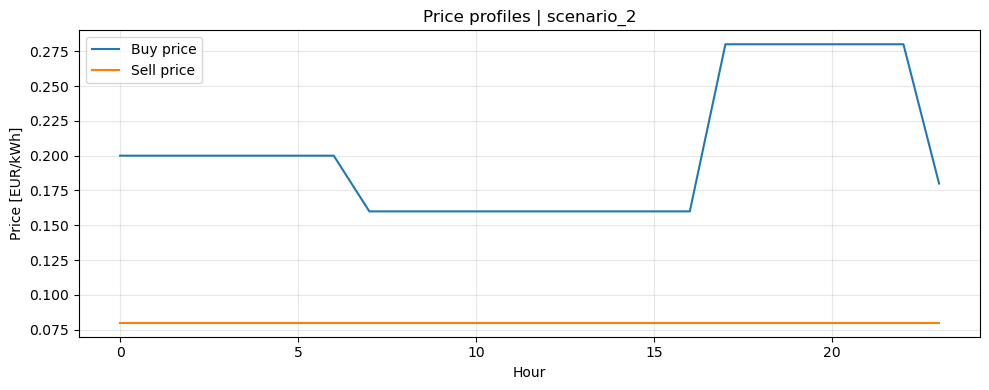

Least-core epsilon: 0.0


,metric,value
0,Grand coalition savings [EUR],2.384477
1,Peak import reduction [%],0.000000
2,PV self-consumption before sharing [%],39.718309
3,PV self-consumption after sharing [%],92.167860
4,PV self-consumption improvement [pp],52.449551


,method,sum_allocation,grand_coalition_value,blocking_coalitions,worst_deficit,in_core,gini
1,least_core,2.384477,2.384477,0,0.000000,True,0.504825
0,shapley,2.384477,2.384477,26,0.084694,False,0.175685
2,equal_split,2.384477,2.384477,37,0.355759,False,0.000000
3,pv_proportional,2.384477,2.384477,112,0.334699,False,0.518882
4,contribution_proportional,2.384477,2.384477,112,0.284128,False,0.535577


,household,shapley_eur,shapley_share_percent,least_core_eur,least_core_share_percent,equal_split_eur,equal_split_share_percent,pv_proportional_eur,pv_proportional_share_percent,contribution_proportional_eur,contribution_proportional_share_percent
0,H1,0.2760,11.5736,0.0429,1.7987,0.2981,12.5,0.5994,25.1367,0.6088,25.5305
1,H2,0.1220,5.1168,0.2132,8.9423,0.2981,12.5,0.0000,0.0000,0.0000,0.0000
2,H3,0.2030,8.5153,0.0271,1.1379,0.2981,12.5,0.5323,22.3247,0.4818,20.2038
3,H4,0.4029,16.8972,0.6746,28.2919,0.2981,12.5,0.0000,0.0000,0.0000,0.0000
4,H5,0.3303,13.8534,0.0693,2.9043,0.2981,12.5,0.6519,27.3388,0.7023,29.4520
5,H6,0.3962,16.6159,0.6655,27.9080,0.2981,12.5,0.0000,0.0000,0.0000,0.0000
6,H7,0.2662,11.1635,0.0401,1.6813,0.2981,12.5,0.6009,25.1998,0.5917,24.8136
7,H8,0.3878,16.2643,0.6518,27.3356,0.2981,12.5,0.0000,0.0000,0.0000,0.0000


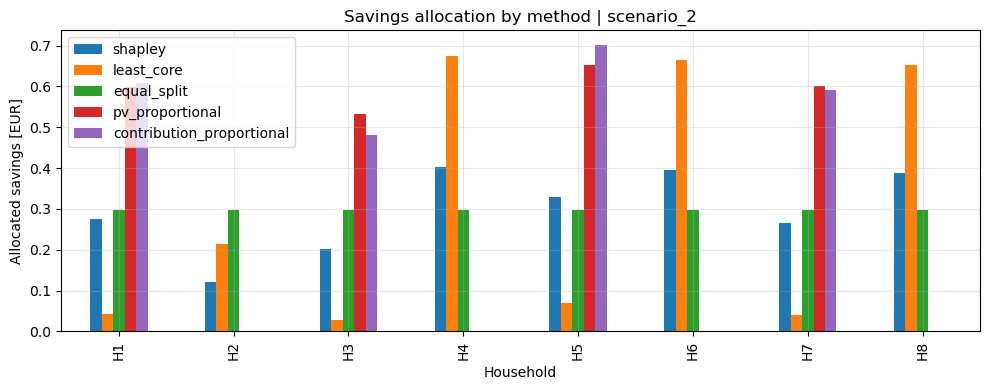

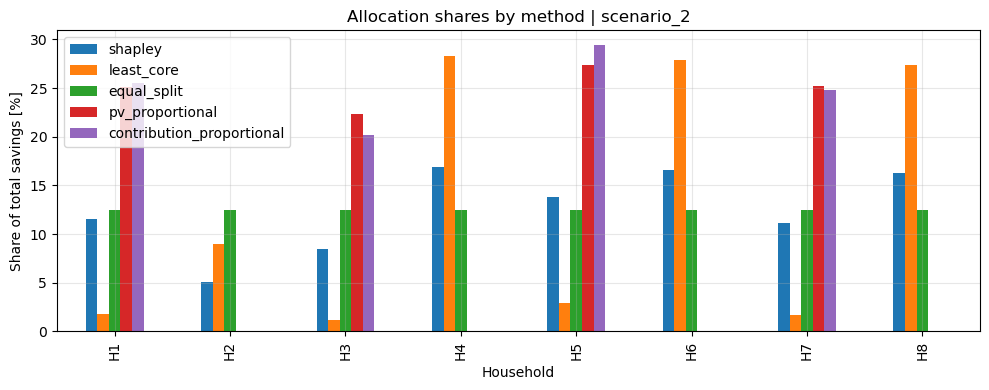

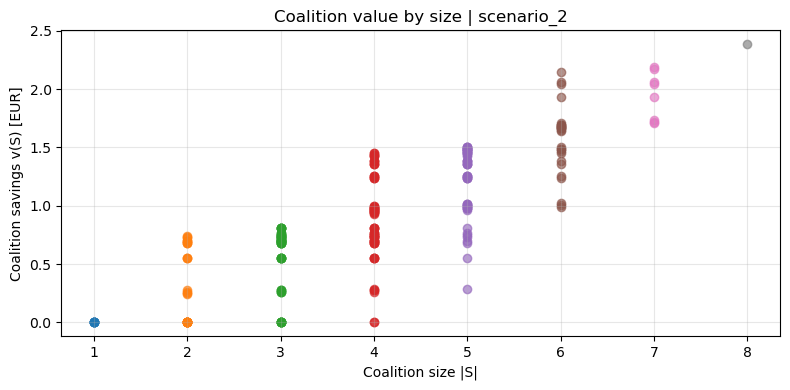

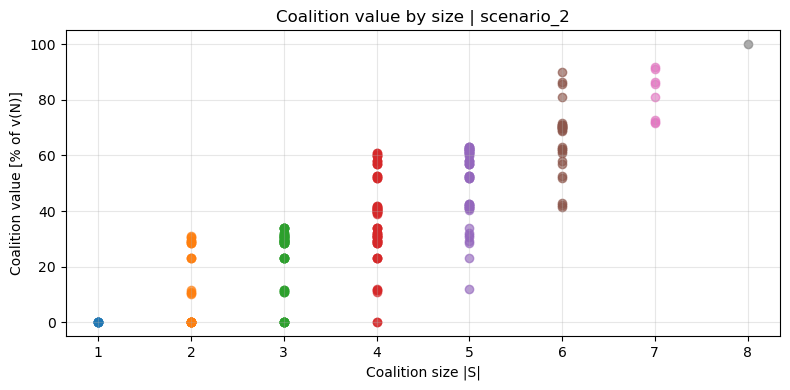

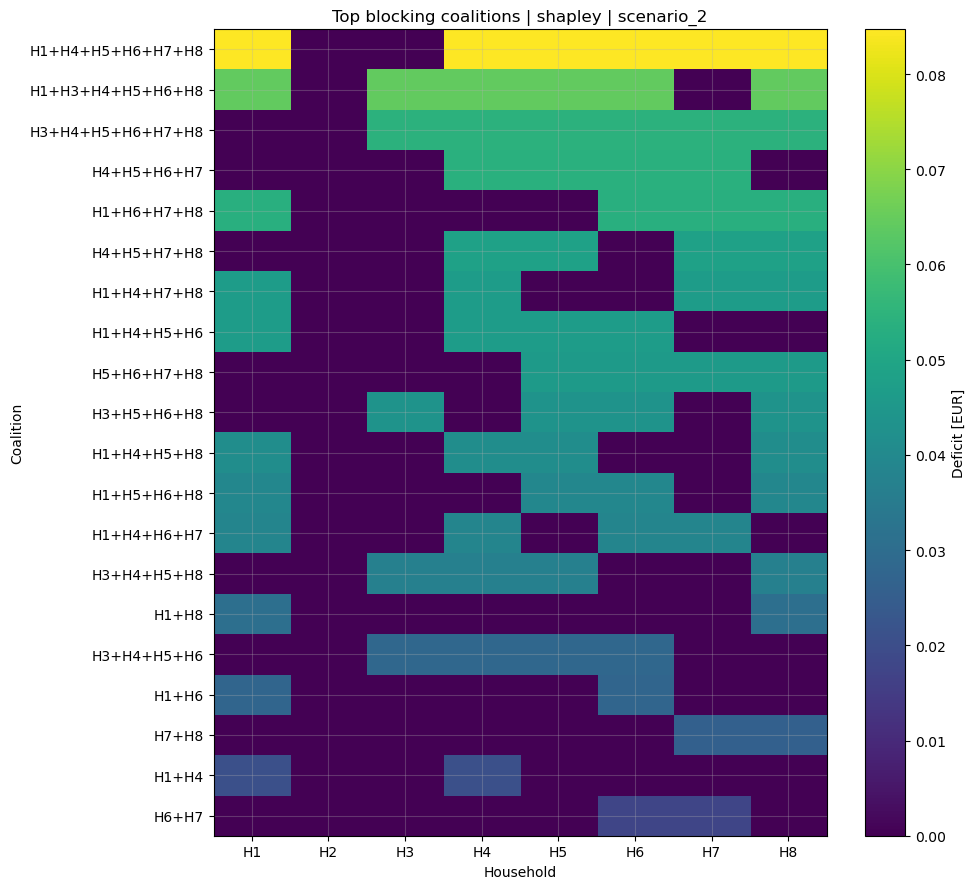

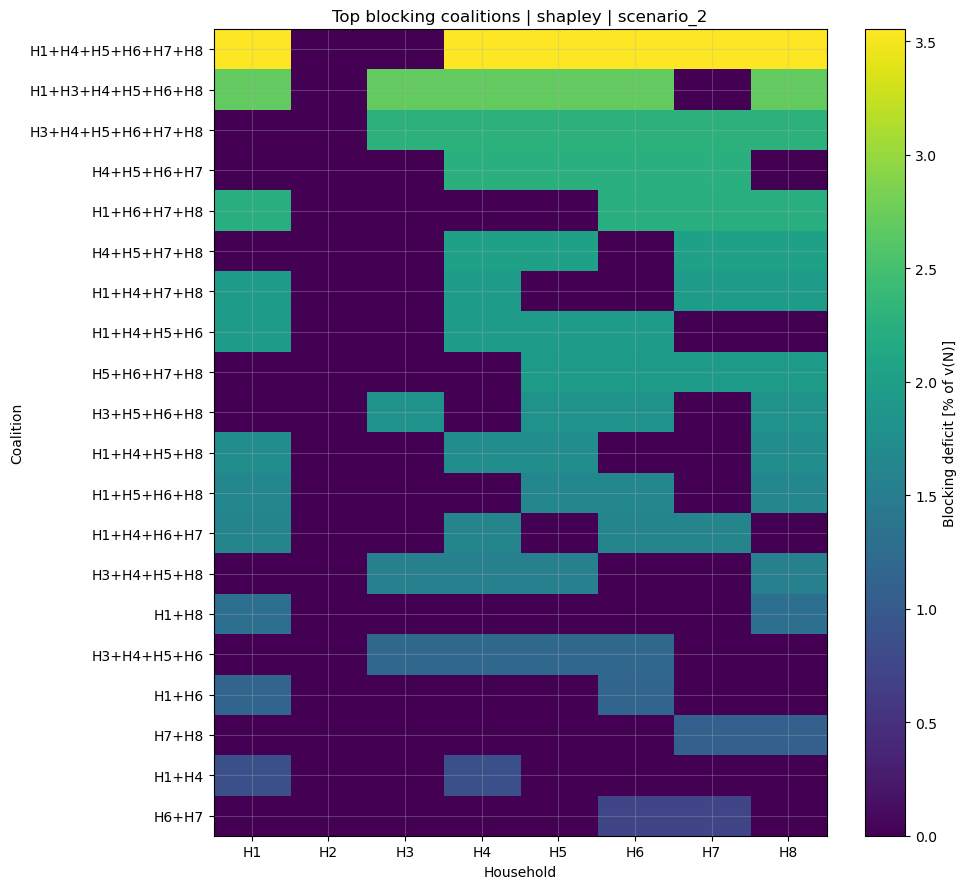

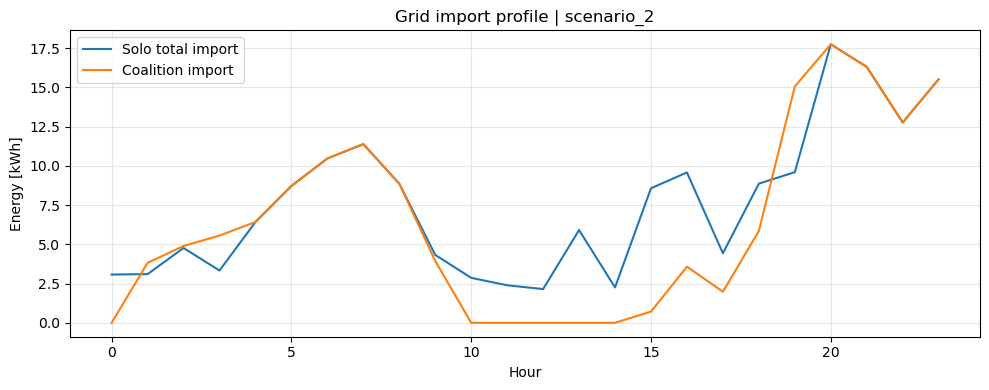

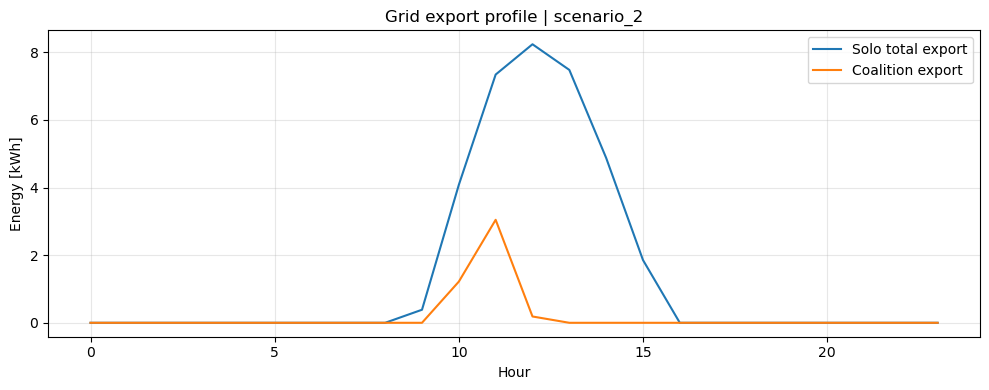

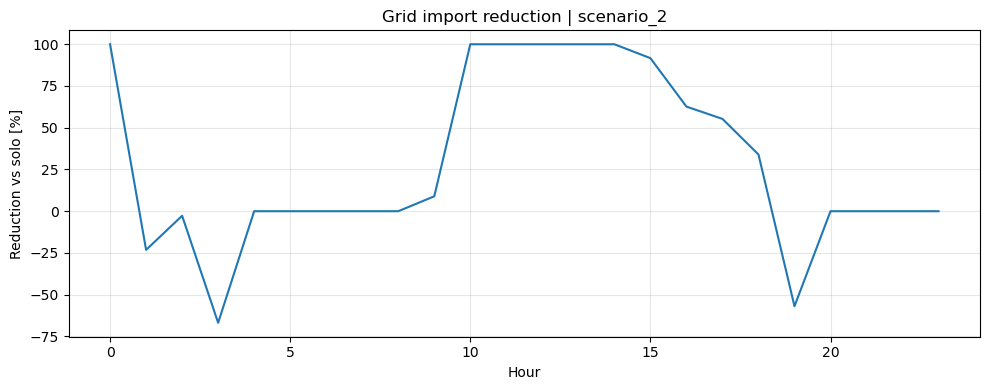

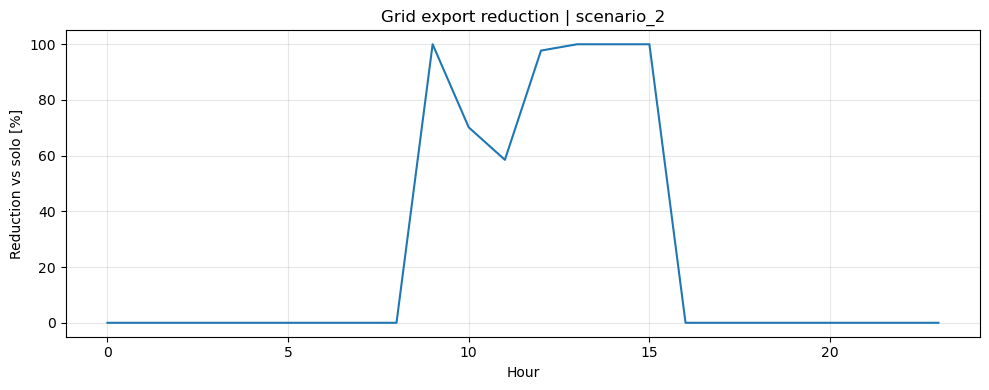

In [16]:
scenario = build_scenario("scenario_2")
plot_input_profiles(scenario)

result = run_analysis(scenario)

print("Least-core epsilon:", result["least_core_eps"])
display(build_system_summary(result))
display(build_method_summary(result))
display(build_household_table(result).round(4))

plot_allocation_bars(result, percent=False)
plot_allocation_bars(result, percent=True)
plot_coalition_values(result, percent=False)
plot_coalition_values(result, percent=True)
plot_blocking_heatmap(result, method="shapley", top_n=20, percent=False)
plot_blocking_heatmap(result, method="shapley", top_n=20, percent=True)
plot_import_export_profiles(result)

In [17]:
all_results = {}

for scenario_name in ["scenario_1", "scenario_2", "scenario_3"]:
    print(f"\n=== Running {scenario_name} ===")
    scenario = build_scenario(scenario_name)
    all_results[scenario_name] = run_analysis(scenario)


=== Running scenario_1 ===

=== Running scenario_2 ===

=== Running scenario_3 ===


In [18]:
summary_rows = []

for scenario_name, result in all_results.items():
    scenario = result["scenario"]
    players = scenario["players"]
    vN = result["game"]["v"][frozenset(players)]
    system_summary = build_system_summary(result)
    method_summary = build_method_summary(result)

    shapley_row = method_summary[method_summary["method"] == "shapley"].iloc[0]
    least_core_row = method_summary[method_summary["method"] == "least_core"].iloc[0]

    summary_rows.append({
        "scenario": scenario_name,
        "grand_coalition_savings_eur": vN,
        "peak_import_reduction_percent": float(system_summary.loc[system_summary["metric"] == "Peak import reduction [%]", "value"].iloc[0]),
        "pv_self_consumption_before_percent": float(system_summary.loc[system_summary["metric"] == "PV self-consumption before sharing [%]", "value"].iloc[0]),
        "pv_self_consumption_after_percent": float(system_summary.loc[system_summary["metric"] == "PV self-consumption after sharing [%]", "value"].iloc[0]),
        "shapley_blocking_coalitions": int(shapley_row["blocking_coalitions"]),
        "shapley_worst_deficit": float(shapley_row["worst_deficit"]),
        "least_core_blocking_coalitions": int(least_core_row["blocking_coalitions"]),
        "least_core_worst_deficit": float(least_core_row["worst_deficit"]),
        "least_core_epsilon": float(result["least_core_eps"]),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

,scenario,grand_coalition_savings_eur,peak_import_reduction_percent,pv_self_consumption_before_percent,pv_self_consumption_after_percent,shapley_blocking_coalitions,shapley_worst_deficit,least_core_blocking_coalitions,least_core_worst_deficit,least_core_epsilon
0,scenario_1,1.2533,0.0,38.9584,85.2368,4,0.0546,0,0.0,0.0
1,scenario_2,2.3845,0.0,39.7183,92.1679,26,0.0847,0,0.0,0.0
2,scenario_3,2.7040,0.0,33.4796,71.3292,90,0.2452,0,0.0,0.0
